# 03 — Pipeline: alerta → incidente → playbook

Simulamos el flujo de automatización de `webhooks.py` + decisión de respuesta (como `playbook_runners.py` en modo simulado).

**Objetivo:** ver métricas de un lote de alertas y qué playbooks se dispararían.

## 1. Qué hace el webhook real (`routes/webhooks.py`)

1. Comprueba `X-API-Key`
2. Normaliza `title`, `severity`, `source`, `src_ip`, `hostname`
3. **Idempotencia** (`Idempotency-Key` / `external_id`) o deduplicación por ventana temporal
4. Crea `Incident` (+ IOC IP opcional)

Imports típicos: `flask`, `datetime`, SQLAlchemy, `logging`.

Aquí lo recreamos **en memoria** (sin BD) para poder graficar.

In [1]:
from __future__ import annotations

from datetime import datetime, timedelta, timezone
from collections import Counter
import hashlib
import re

import pandas as pd
import matplotlib.pyplot as plt

SEVERITIES = ("critical", "high", "medium", "low")
IP_PATTERN = re.compile(
    r"^(?:(?:25[0-5]|2[0-4]\d|[01]?\d?\d)(?:\.|$)){4}$"
)


def normalize_alert(payload: dict) -> dict:
    """Equivalente pedagógico a la normalización de webhooks.receive_alert."""
    severity = payload.get("severity", "medium")
    if severity not in SEVERITIES:
        severity = "medium"
    src_ip = (payload.get("src_ip") or payload.get("ip") or "").strip() or None
    return {
        "title": (payload.get("title") or "Alerta webhook")[:200],
        "severity": severity,
        "source": (payload.get("source") or "Webhook")[:100],
        "src_ip": src_ip,
        "hostname": (payload.get("hostname") or "").strip() or None,
        "external_id": payload.get("external_id") or payload.get("alert_id"),
        "received_at": datetime.now(timezone.utc),
    }


def simulate_risk(ip: str | None) -> int:
    if not ip or not IP_PATTERN.match(ip):
        return 0
    return int(hashlib.md5(ip.encode()).hexdigest(), 16) % 101


def decide_playbooks(incident: dict, risk: int) -> list[str]:
    """Reglas de automatización de ejemplo (SOC playbook selection)."""
    actions = []
    if risk >= 75 and incident.get("src_ip"):
        actions.append("block_ip")
    if incident["severity"] in ("critical", "high") and incident.get("hostname"):
        actions.append("isolate_host")
    if "credential" in incident["title"].lower() or "brute" in incident["title"].lower():
        actions.append("revoke_user")
    if not actions:
        actions.append("data_scan")
    return actions


def run_playbook_simulated(playbook_id: str, params: dict) -> dict:
    """Equivalente a playbook_runners._simulate."""
    catalog = {
        "isolate_host": f"Host {params.get('hostname', '?')} aislado (simulado)",
        "block_ip": f"IP {params.get('ip', '?')} bloqueada (simulado)",
        "revoke_user": f"Usuario {params.get('username', 'suspect')} revocado (simulado)",
        "data_scan": f"Escaneo en {params.get('target', 'endpoint')} (simulado)",
    }
    return {
        "playbook_id": playbook_id,
        "status": "completed",
        "mode": "simulated",
        "result": catalog.get(playbook_id, "desconocido"),
    }

print("Pipeline helpers OK")

Pipeline helpers OK


## 2. Lote de alertas (como las enviaría Splunk/Wazuh)

In [2]:
ALERTAS_RAW = [
    {"title": "Brute force SSH", "severity": "high", "source": "Splunk", "src_ip": "198.51.100.42", "hostname": "SRV-SSH-01", "alert_id": "A-1001"},
    {"title": "Malware detectado", "severity": "critical", "source": "CrowdStrike", "src_ip": "203.0.113.50", "hostname": "HR-042", "alert_id": "A-1002"},
    {"title": "Exfiltración DLP 2.3GB", "severity": "critical", "source": "DLP", "src_ip": "203.0.113.10", "hostname": "SRV-FIN-01", "alert_id": "A-1003"},
    {"title": "Scan de puertos", "severity": "medium", "source": "IDS", "src_ip": "192.0.2.55", "alert_id": "A-1004"},
    {"title": "Phishing click", "severity": "medium", "source": "Email", "src_ip": "8.8.8.8", "alert_id": "A-1005"},
    {"title": "Credential stuffing", "severity": "high", "source": "Wazuh", "src_ip": "185.220.101.1", "hostname": "WEB-01", "alert_id": "A-1006"},
    {"title": "DNS tunneling sospechoso", "severity": "high", "source": "QRadar", "src_ip": "45.33.32.156", "hostname": "WS-DEV-12", "alert_id": "A-1007"},
    {"title": "Login OK VPN", "severity": "low", "source": "Firewall", "src_ip": "10.0.0.5", "alert_id": "A-1008"},
    # Duplicado (misma alert_id) — debería deduplicarse
    {"title": "Brute force SSH", "severity": "high", "source": "Splunk", "src_ip": "198.51.100.42", "hostname": "SRV-SSH-01", "alert_id": "A-1001"},
]

incidents = []
seen_ids = set()
duplicates = 0
playbook_log = []

for raw in ALERTAS_RAW:
    inc = normalize_alert(raw)
    eid = inc.get("external_id")
    if eid and eid in seen_ids:
        duplicates += 1
        continue
    if eid:
        seen_ids.add(eid)

    risk = simulate_risk(inc["src_ip"])
    actions = decide_playbooks(inc, risk)
    for pb in actions:
        params = {
            "ip": inc.get("src_ip"),
            "hostname": inc.get("hostname"),
            "username": "suspect",
            "target": inc.get("hostname") or "endpoint",
        }
        result = run_playbook_simulated(pb, params)
        playbook_log.append({**result, "alert": inc["title"], "severity": inc["severity"]})

    incidents.append({**inc, "risk_score": risk, "playbooks": ",".join(actions)})

df_inc = pd.DataFrame(incidents)
df_pb = pd.DataFrame(playbook_log)

print(f"Alertas recibidas: {len(ALERTAS_RAW)}")
print(f"Duplicados omitidos: {duplicates}")
print(f"Incidentes creados: {len(df_inc)}")
print(f"Ejecuciones playbook: {len(df_pb)}")
display(df_inc[["title", "severity", "source", "src_ip", "risk_score", "playbooks"]])

Alertas recibidas: 9
Duplicados omitidos: 1
Incidentes creados: 8
Ejecuciones playbook: 12


,title,severity,source,src_ip,risk_score,playbooks
0,Brute force SSH,high,Splunk,198.51.100.42,32,"isolate_host,revoke_user"
1,Malware detectado,critical,CrowdStrike,203.0.113.50,98,"block_ip,isolate_host"
2,Exfiltración DLP 2.3GB,critical,DLP,203.0.113.10,61,isolate_host
3,Scan de puertos,medium,IDS,192.0.2.55,75,block_ip
4,Phishing click,medium,Email,8.8.8.8,45,data_scan
5,Credential stuffing,high,Wazuh,185.220.101.1,79,"block_ip,isolate_host,revoke_user"
6,DNS tunneling sospechoso,high,QRadar,45.33.32.156,36,isolate_host
7,Login OK VPN,low,Firewall,10.0.0.5,30,data_scan


## 3. Métricas y gráficos del pipeline

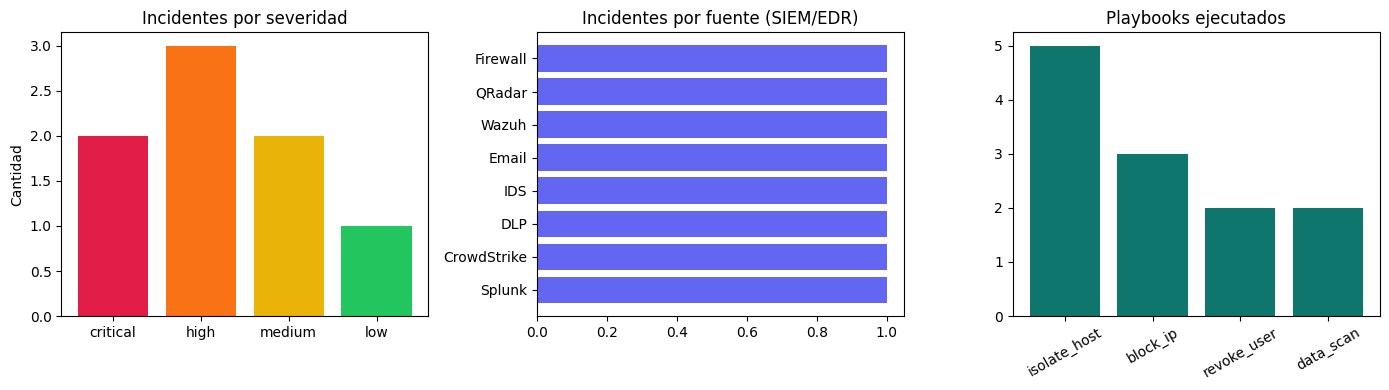


=== KPIs del laboratorio ===
Tasa de deduplicación: 1/9 = 11%
% critical+high: 62%
Media risk_score: 57.0
Playbooks / incidente: 1.50


In [3]:
sev_order = ["critical", "high", "medium", "low"]
sev_counts = df_inc["severity"].value_counts().reindex(sev_order).fillna(0).astype(int)
src_counts = df_inc["source"].value_counts()
pb_counts = df_pb["playbook_id"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sev_colors = {"critical": "#e11d48", "high": "#f97316", "medium": "#eab308", "low": "#22c55e"}
axes[0].bar(sev_counts.index, sev_counts.values, color=[sev_colors[s] for s in sev_counts.index])
axes[0].set_title("Incidentes por severidad")
axes[0].set_ylabel("Cantidad")

axes[1].barh(src_counts.index, src_counts.values, color="#6366f1")
axes[1].set_title("Incidentes por fuente (SIEM/EDR)")

axes[2].bar(pb_counts.index, pb_counts.values, color="#0f766e")
axes[2].set_title("Playbooks ejecutados")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\n=== KPIs del laboratorio ===")
print(f"Tasa de deduplicación: {duplicates}/{len(ALERTAS_RAW)} = {100*duplicates/len(ALERTAS_RAW):.0f}%")
print(f"% critical+high: {100 * df_inc['severity'].isin(['critical','high']).mean():.0f}%")
print(f"Media risk_score: {df_inc['risk_score'].mean():.1f}")
print(f"Playbooks / incidente: {len(df_pb)/len(df_inc):.2f}")

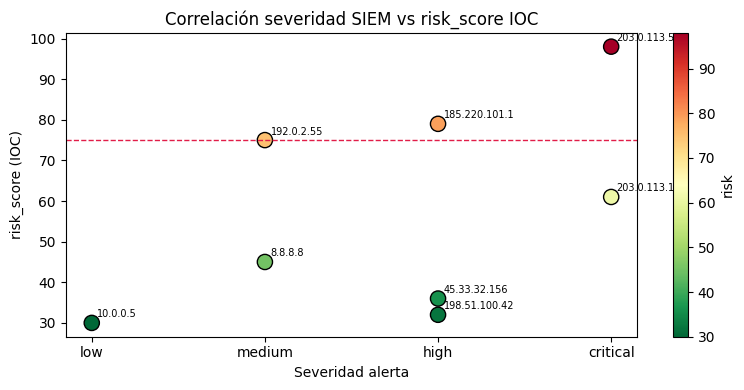

,playbook_id,status,mode,result,alert,severity
0,isolate_host,completed,simulated,Host SRV-SSH-01 aislado (simulado),Brute force SSH,high
1,revoke_user,completed,simulated,Usuario suspect revocado (simulado),Brute force SSH,high
2,block_ip,completed,simulated,IP 203.0.113.50 bloqueada (simulado),Malware detectado,critical
3,isolate_host,completed,simulated,Host HR-042 aislado (simulado),Malware detectado,critical
4,isolate_host,completed,simulated,Host SRV-FIN-01 aislado (simulado),Exfiltración DLP 2.3GB,critical
5,block_ip,completed,simulated,IP 192.0.2.55 bloqueada (simulado),Scan de puertos,medium
6,data_scan,completed,simulated,Escaneo en endpoint (simulado),Phishing click,medium
7,block_ip,completed,simulated,IP 185.220.101.1 bloqueada (simulado),Credential stuffing,high
8,isolate_host,completed,simulated,Host WEB-01 aislado (simulado),Credential stuffing,high
9,revoke_user,completed,simulated,Usuario suspect revocado (simulado),Credential stuffing,high


In [4]:
# Timeline simple: riesgo vs severidad
sev_num = {"low": 1, "medium": 2, "high": 3, "critical": 4}
df_inc["sev_n"] = df_inc["severity"].map(sev_num)

fig, ax = plt.subplots(figsize=(8, 4))
scatter = ax.scatter(
    df_inc["sev_n"],
    df_inc["risk_score"],
    s=120,
    c=df_inc["risk_score"],
    cmap="RdYlGn_r",
    edgecolors="black",
)
for _, row in df_inc.iterrows():
    ax.annotate(row["src_ip"] or "-", (row["sev_n"], row["risk_score"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["low", "medium", "high", "critical"])
ax.set_ylabel("risk_score (IOC)")
ax.set_xlabel("Severidad alerta")
ax.set_title("Correlación severidad SIEM vs risk_score IOC")
ax.axhline(75, linestyle="--", color="#e11d48", linewidth=1)
plt.colorbar(scatter, ax=ax, label="risk")
plt.tight_layout()
plt.show()

display(df_pb)

## 4. Relación con métricas Prometheus del producto

En producción (`metrics.py`) SecOps Hub expone:

| Métrica | Tipo | Significado |
|---------|------|-------------|
| `secops_http_requests_total` | Counter | Peticiones HTTP |
| `secops_http_request_duration_seconds` | Histogram | Latencia |
| `secops_incidents_open` | Gauge | Incidentes open/investigating |
| `secops_users_active` | Gauge | Usuarios activos |

Este notebook calcula KPIs **equivalentes en lab** sin levantar Prometheus.

```python
# En el producto real:
from prometheus_client import Counter, Gauge, Histogram
```

,métrica,valor
0,alertas_recibidas,9
1,incidentes_abiertos_lab,8
2,duplicados,1
3,playbooks_ejecutados,12
4,block_ip,3
5,isolate_host,5
6,revoke_user,2


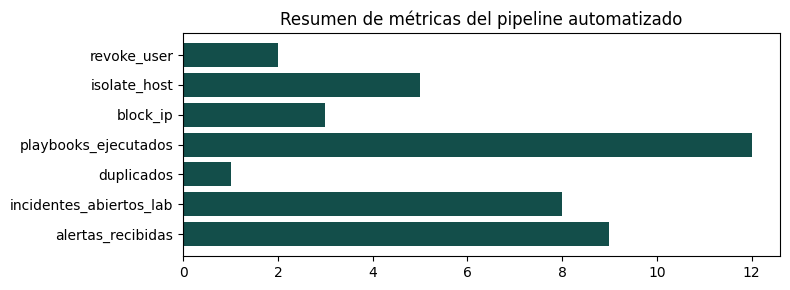

In [5]:
# Mini "dashboard" tabular de métricas del ejercicio
kpis = pd.DataFrame([
    {"métrica": "alertas_recibidas", "valor": len(ALERTAS_RAW)},
    {"métrica": "incidentes_abiertos_lab", "valor": len(df_inc)},
    {"métrica": "duplicados", "valor": duplicates},
    {"métrica": "playbooks_ejecutados", "valor": len(df_pb)},
    {"métrica": "block_ip", "valor": int((df_pb["playbook_id"] == "block_ip").sum())},
    {"métrica": "isolate_host", "valor": int((df_pb["playbook_id"] == "isolate_host").sum())},
    {"métrica": "revoke_user", "valor": int((df_pb["playbook_id"] == "revoke_user").sum())},
])
display(kpis)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(kpis["métrica"], kpis["valor"], color="#134e4a")
ax.set_title("Resumen de métricas del pipeline automatizado")
plt.tight_layout()
plt.show()

## 5. Conclusión formativa

| Paso SOC | Automatizado con Python en SecOps Hub |
|----------|----------------------------------------|
| Recibir alerta SIEM | `webhooks.py` + Flask |
| Evitar duplicados | `external_id` / ventana temporal |
| Clasificar IOC | `re` + `hashlib` + scoring |
| Decidir respuesta | Reglas + playbooks (`requests` en live) |
| Medir operación | Prometheus / este lab con pandas+matplotlib |

Has completado el itinerario de `formacion/`. Siguiente paso en el producto real: arrancar Docker y enviar un webhook real (ver `docs/laboratorio-infraestructura.md`).